<a href="https://colab.research.google.com/github/akshithsingh/VRSU/blob/main/Program_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving a-vibrant-green-tree-stands-prominently-on-a-hillside-filled-with-small-white-flowers-against-a-lush-forest-backdrop-photo.jpg to a-vibrant-green-tree-stands-prominently-on-a-hillside-filled-with-small-white-flowers-against-a-lush-forest-backdrop-photo.jpg


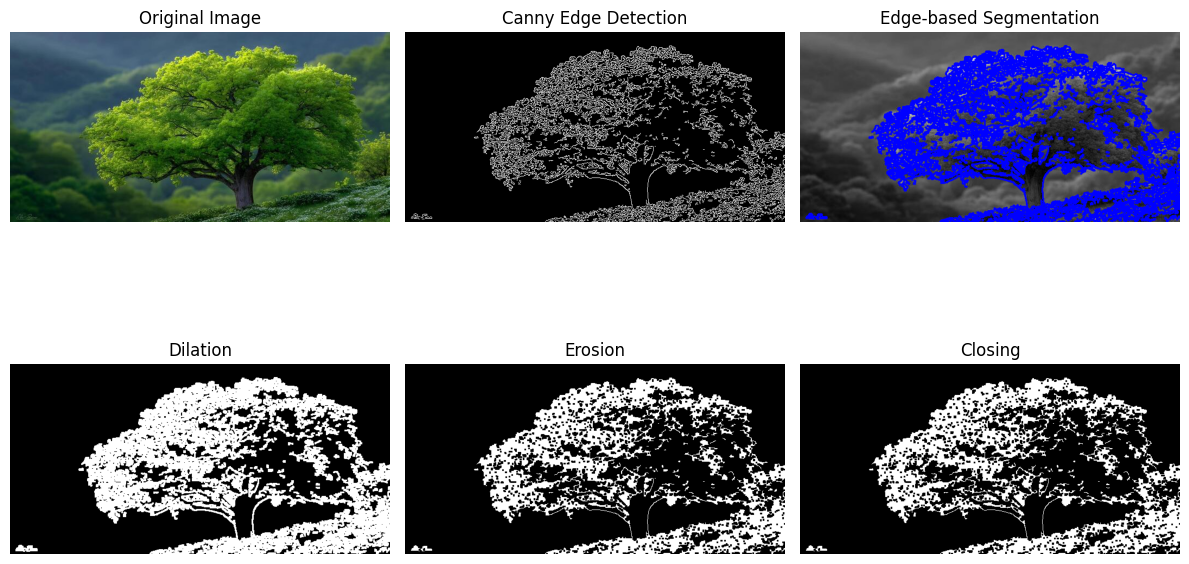

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files


uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Read image
img_gray = cv2.imread(image_path, 0)
img_color = cv2.imread(image_path)

if img_gray is None:
    raise ValueError("Failed to load image!")

# Convert BGR to RGB for display
img_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)


edges = cv2.Canny(img_gray, 100, 200)

contours, _ = cv2.findContours(
    edges,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

segmented = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)
cv2.drawContours(segmented, contours, -1, (0, 0, 255), 2)


kernel = np.ones((3, 3), np.uint8)

dilated = cv2.dilate(edges, kernel, iterations=1)

eroded = cv2.erode(dilated, kernel, iterations=1)


opening = cv2.morphologyEx(edges, cv2.MORPH_OPEN, kernel)

closing = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)


plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.title("Original Image")
plt.imshow(img_rgb)
plt.axis("off")

plt.subplot(2, 3, 2)
plt.title("Canny Edge Detection")
plt.imshow(edges, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.title("Edge-based Segmentation")
plt.imshow(segmented)
plt.axis("off")

plt.subplot(2, 3, 4)
plt.title("Dilation")
plt.imshow(dilated, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.title("Erosion")
plt.imshow(eroded, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.title("Closing")
plt.imshow(closing, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()
